In [34]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')


In [35]:
df2024 = pd.read_csv('../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../Data/Zero/2025_data.csv')
stock_info = pd.read_csv('../../Data/은평구_스테이션_군집화_1차_자전거댓수_추가.csv')

df = pd.concat([df2024, df2025], axis=0, ignore_index=True)
raw_rows = len(df)
df = df.drop_duplicates().copy()
print(f"removed exact duplicates: {raw_rows - len(df):,}")

kr = holidays.KR()


removed exact duplicates: 161,864


In [36]:
# 1. 시작 대여소 기준으로만 필터링 (순수 대여량 예측 목적)
target_station = ['ST-464', 'ST-481', 'ST-479']
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['year'] = df['기준_날짜'].dt.year
df['weekday'] = df['기준_날짜'].dt.dayofweek
df['day_type'] = np.where(df['weekday'] < 5, 0, 1)
df = df[(df['전체_이용_분'] >= 5) & (df['전체_이용_거리'] >= 5)]
df['datetime'] = pd.to_datetime(df['기준_날짜']) + pd.to_timedelta(df['시간대'], unit='h')
df = df[df['시작_대여소_ID'].isin(target_station)].copy()
df_hourly = df.groupby(['시작_대여소_ID', 'datetime','year']).agg({
    '전체_건수': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'mean',
    '적설량': 'mean'
}).reset_index()


In [37]:
df

,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량,year,weekday,day_type,datetime
3,2024-01-01,0,출발시간,ST-479,ST-454,2.0,1200,2953.0,-2.7,92,28.49784,0.0,0.0,2024,0,0,2024-01-01 00:00:00
69,2024-01-01,7,출발시간,ST-481,ST-454,1.0,240,771.0,-1.4,90,31.04860,0.0,0.0,2024,0,0,2024-01-01 07:00:00
136,2024-01-01,14,출발시간,ST-464,ST-454,1.0,360,1052.0,6.1,65,45.87135,0.0,0.0,2024,0,0,2024-01-01 14:00:00
153,2024-01-01,15,출발시간,ST-481,ST-454,2.0,900,1511.0,6.6,59,47.06406,0.0,0.0,2024,0,0,2024-01-01 15:00:00
168,2024-01-01,16,출발시간,ST-479,ST-454,1.0,420,1390.0,6.1,65,45.87135,0.0,0.0,2024,0,0,2024-01-01 16:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347190,2025-12-31,15,출발시간,ST-464,ST-454,1.0,2340,1927.0,-4.4,31,36.95264,0.0,0.0,2025,2,0,2025-12-31 15:00:00
347194,2025-12-31,15,출발시간,ST-481,ST-454,1.0,240,642.0,-4.4,31,36.95264,0.0,0.0,2025,2,0,2025-12-31 15:00:00
347235,2025-12-31,18,출발시간,ST-481,ST-454,1.0,360,843.0,-6.6,42,32.20372,0.0,0.0,2025,2,0,2025-12-31 18:00:00
347240,2025-12-31,18,출발시간,ST-481,ST-1035,1.0,420,998.0,-6.6,42,32.20372,0.0,0.0,2025,2,0,2025-12-31 18:00:00


In [38]:
# 시간 정보 생성
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)
df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)


In [39]:
all_stations = df_hourly['시작_대여소_ID'].unique()
all_times = pd.date_range(
    start=df_hourly['datetime'].min(),
    end=df_hourly['datetime'].max(),
    freq='h'
)

multi_idx = pd.MultiIndex.from_product(
    [all_stations, all_times],
    names=['시작_대여소_ID', 'datetime']
)
df_full = pd.DataFrame(index=multi_idx).reset_index()

df_hourly = pd.merge(df_full, df_hourly, on=['시작_대여소_ID', 'datetime'], how='left')
df_hourly['전체_건수'] = df_hourly['전체_건수'].fillna(0)
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)
df_hourly['cycle_flag'] = (df_hourly['hour'] == 16).astype(int)

weather_cols = ['온도', '습도', '불쾌지수', '강수량', '적설량']
df_hourly[weather_cols] = (
    df_hourly.groupby('시작_대여소_ID')[weather_cols]
    .transform(lambda x: x.ffill().bfill())
)

df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime']).copy()
df_hourly['future_12h_demand'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].transform(
    lambda x: x.rolling(12).sum().shift(-11)
)

stock_map = stock_info[['대여소_ID', 'LCD', 'QR']].rename(columns={'대여소_ID': '시작_대여소_ID'}).copy()
stock_map['station_capacity'] = stock_map['LCD'].fillna(0) + stock_map['QR'].fillna(0)
df_hourly = df_hourly.merge(stock_map[['시작_대여소_ID', 'station_capacity']], on='시작_대여소_ID', how='left')
df_hourly['station_capacity'] = df_hourly['station_capacity'].fillna(0)

df_model = df_hourly[df_hourly['hour'].isin([4, 16])].copy()
df_model = df_model.sort_values(['시작_대여소_ID', 'datetime']).copy()
df_model['station_idx'] = pd.factorize(df_model['시작_대여소_ID'])[0]
df_model['prev_cycle_demand'] = df_model.groupby('시작_대여소_ID')['future_12h_demand'].shift(1)
df_model['prev_same_cycle_demand'] = df_model.groupby('시작_대여소_ID')['future_12h_demand'].shift(2)

df_model = df_model.dropna(subset=['future_12h_demand', 'prev_cycle_demand', 'prev_same_cycle_demand'])

target = 'future_12h_demand'
base_features = [
    'weekday',
    'cycle_flag',
    '온도', '습도',
    '강수량', '적설량',
    'prev_cycle_demand',
    'prev_same_cycle_demand',
    'station_capacity',
]
features = base_features.copy()            # 기본 모델: station 정보 제외
features_station_idx = base_features + ['station_idx']


In [40]:
nan_summary = df_model[base_features + ['station_idx', target]].isna().sum().sort_values(ascending=False)
display(nan_summary[nan_summary > 0])
print('rows after preprocessing:', len(df_model))
print('using features:', features)
print('using station_idx comparison features:', features_station_idx)
print('operational target:', target)
print('at inference time -> required_bikes = predicted_future_12h_demand - current_live_stock(LCD+QR)')
print('note: current_live_stock is not in historical training data, so it should be injected at prediction time.')


Series([], dtype: int64)

rows after preprocessing: 4377
using features: ['weekday', 'cycle_flag', '온도', '습도', '강수량', '적설량', 'prev_cycle_demand', 'prev_same_cycle_demand', 'station_capacity']
using station_idx comparison features: ['weekday', 'cycle_flag', '온도', '습도', '강수량', '적설량', 'prev_cycle_demand', 'prev_same_cycle_demand', 'station_capacity', 'station_idx']
operational target: future_12h_demand
at inference time -> required_bikes = predicted_future_12h_demand - current_live_stock(LCD+QR)
note: current_live_stock is not in historical training data, so it should be injected at prediction time.


==============================

In [41]:
fit = df_model[df_model['datetime'] < '2024-11-01'].copy()
valid = df_model[
    (df_model['datetime'] >= '2024-11-01') &
    (df_model['datetime'] < '2025-01-01')
].copy()
train_2024 = df_model[df_model['year'] == 2024].copy()
test = df_model[df_model['year'] == 2025].copy()

X_fit = fit[features]
y_fit = fit[target]

X_valid = valid[features]
y_valid = valid[target]

X_train = train_2024[features]
y_train = train_2024[target]

X_test = test[features]
y_test = test[target]

hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

# 2024 후반 holdout 검증
hgb.fit(X_fit, np.log1p(y_fit))

print('Holdout Train score(log):', hgb.score(X_fit, np.log1p(y_fit)))
print('Holdout Valid score(log):', hgb.score(X_valid, np.log1p(y_valid)))

pred_fit = np.expm1(hgb.predict(X_fit))
pred_valid = np.expm1(hgb.predict(X_valid))

print('========================')
print('FIT MAE:', mean_absolute_error(y_fit, pred_fit))
print('FIT RMSE:', np.sqrt(mean_squared_error(y_fit, pred_fit)))
print('FIT R2:', r2_score(y_fit, pred_fit))

print('========================')
print('VALID MAE:', mean_absolute_error(y_valid, pred_valid))
print('VALID RMSE:', np.sqrt(mean_squared_error(y_valid, pred_valid)))
print('VALID R2:', r2_score(y_valid, pred_valid))

# 최종 모델은 2024 전체로 재학습 후 2025 평가
hgb_final = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)
hgb_final.fit(X_train, np.log1p(y_train))

print('========================')
print('All 2024 score(log):', hgb_final.score(X_train, np.log1p(y_train)))
print('Test 2025 score(log):', hgb_final.score(X_test, np.log1p(y_test)))

pred_train = np.expm1(hgb_final.predict(X_train))
pred_test = np.expm1(hgb_final.predict(X_test))

print('========================')
print('Train MAE:', mean_absolute_error(y_train, pred_train))
print('Train RMSE:', np.sqrt(mean_squared_error(y_train, pred_train)))
print('Train R2:', r2_score(y_train, pred_train))

print('========================')
print('TEST MAE:', mean_absolute_error(y_test, pred_test))
print('TEST RMSE:', np.sqrt(mean_squared_error(y_test, pred_test)))
print('TEST R2:', r2_score(y_test, pred_test))


Holdout Train score(log): 0.843883823304988
Holdout Valid score(log): 0.24132990786141495
FIT MAE: 0.9720731681884499
FIT RMSE: 1.4971994344492823
FIT R2: 0.8103183768502962
VALID MAE: 1.9597689952370578
VALID RMSE: 2.7220142650808485
VALID R2: 0.3334266058695211
All 2024 score(log): 0.8152647978378589
Test 2025 score(log): 0.20228806740886907
Train MAE: 1.055453162634345
Train RMSE: 1.603678903696336
Train R2: 0.7803135134036833
TEST MAE: 1.7282173529341283
TEST RMSE: 2.3717041448450775
TEST R2: 0.26080277312470024


In [42]:
from sklearn.dummy import DummyRegressor

def evaluate_model(train_df, eval_df, feat_cols, label):
    model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )
    model.fit(train_df[feat_cols], np.log1p(train_df[target]))
    pred = np.expm1(model.predict(eval_df[feat_cols]))
    return {
        'model': label,
        'MAE': mean_absolute_error(eval_df[target], pred),
        'RMSE': np.sqrt(mean_squared_error(eval_df[target], pred)),
        'R2': r2_score(eval_df[target], pred)
    }

def feature_overlap_ratio(left_df, right_df, cols):
    left_hash = set(pd.util.hash_pandas_object(left_df[cols].fillna(-9999), index=False).astype(str))
    right_hash = set(pd.util.hash_pandas_object(right_df[cols].fillna(-9999), index=False).astype(str))
    if not right_hash:
        return 0.0
    return len(left_hash & right_hash) / len(right_hash)

cycleless_features = [col for col in features if col != 'prev_cycle_demand']

diagnostics = []
diagnostics.append(evaluate_model(fit, valid, features, 'no_station'))
diagnostics.append(evaluate_model(fit, valid, features_station_idx, 'station_idx_only'))
diagnostics.append(evaluate_model(fit, valid, cycleless_features, 'no_prev_cycle'))

dummy = DummyRegressor(strategy='mean')
dummy.fit(fit[features], fit[target])
dummy_pred = dummy.predict(valid[features])
diagnostics.append({
    'model': 'dummy_mean',
    'MAE': mean_absolute_error(valid[target], dummy_pred),
    'RMSE': np.sqrt(mean_squared_error(valid[target], dummy_pred)),
    'R2': r2_score(valid[target], dummy_pred)
})

prev_cycle_pred = valid['prev_cycle_demand'].to_numpy()
diagnostics.append({
    'model': 'naive_prev_cycle',
    'MAE': mean_absolute_error(valid[target], prev_cycle_pred),
    'RMSE': np.sqrt(mean_squared_error(valid[target], prev_cycle_pred)),
    'R2': r2_score(valid[target], prev_cycle_pred)
})

shuffled_fit = fit.copy()
shuffled_fit[target] = fit[target].sample(frac=1, random_state=42).to_numpy()
diagnostics.append(evaluate_model(shuffled_fit, valid, features, 'shuffled_target'))

diag_df = pd.DataFrame(diagnostics).sort_values('R2', ascending=False)
display(diag_df)

print('target std (valid):', valid[target].std())
print('target mean (valid):', valid[target].mean())
print('fit-valid exact feature overlap:', round(feature_overlap_ratio(fit, valid, features), 4))
print('train2024-test2025 exact feature overlap:', round(feature_overlap_ratio(train_2024, test, features), 4))

feature_corr = train_2024[base_features + [target]].corr(numeric_only=True)[target].drop(target).sort_values(key=np.abs, ascending=False)
display(feature_corr.to_frame('corr_with_target'))

print('Leakage guide:')
print('- shuffled_target R2가 0보다 훨씬 크면 누수 가능성이 큽니다.')
print('- station_idx_only가 no_station보다 과도하게 좋으면 station 정보 의존도가 큽니다.')
print('- no_station과 naive_prev_cycle가 거의 같으면 모델이 사실상 직전 12시간 복사에 가깝습니다.')
print('- exact feature overlap가 높으면 split 간 중복/재등장 패턴을 의심해야 합니다.')


,model,MAE,RMSE,R2
1,station_idx_only,1.941119,2.697886,0.345192
2,no_prev_cycle,1.920932,2.710958,0.338831
0,no_station,1.959769,2.722014,0.333427
3,dummy_mean,2.575889,3.340714,-0.004028
5,shuffled_target,2.508742,3.616289,-0.176504
4,naive_prev_cycle,3.174863,4.454383,-0.785017


target std (valid): 3.338570255535899
target mean (valid): 3.3251366120218577
fit-valid exact feature overlap: 0.0
train2024-test2025 exact feature overlap: 0.0005


,corr_with_target
prev_same_cycle_demand,0.534593
prev_cycle_demand,0.246727
cycle_flag,-0.208192
station_capacity,0.103686
온도,0.101392
습도,0.081881
강수량,-0.024126
weekday,-0.021552
적설량,-0.018568


Leakage guide:
- shuffled_target R2가 0보다 훨씬 크면 누수 가능성이 큽니다.
- station_idx_only가 no_station보다 과도하게 좋으면 station 정보 의존도가 큽니다.
- no_station과 naive_prev_cycle가 거의 같으면 모델이 사실상 직전 12시간 복사에 가깝습니다.
- exact feature overlap가 높으면 split 간 중복/재등장 패턴을 의심해야 합니다.


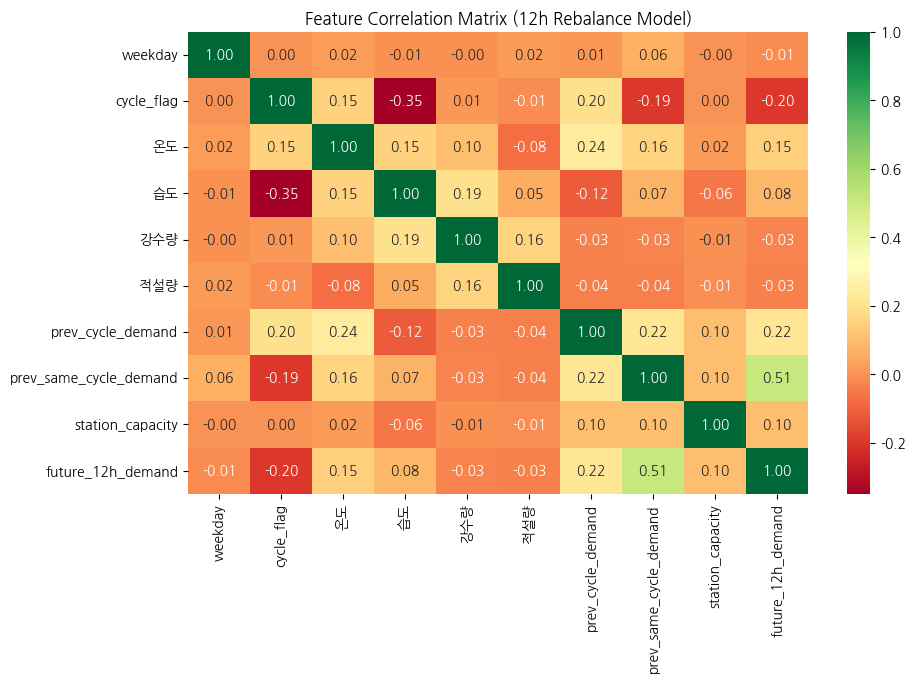

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = df_model[base_features + [target]]

plt.figure(figsize=(10, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Matrix (12h Rebalance Model)')
plt.show()


In [44]:
corr_df

,weekday,cycle_flag,온도,습도,강수량,적설량,prev_cycle_demand,prev_same_cycle_demand,station_capacity,future_12h_demand
28,1,0,4.3,78.0,0.0,0.0,1.0,1.0,13.0,0.0
40,1,1,3.7,59.0,0.0,0.0,0.0,1.0,13.0,4.0
52,2,0,3.7,59.0,0.0,0.0,4.0,0.0,13.0,0.0
64,2,1,3.7,59.0,0.0,0.0,0.0,4.0,13.0,1.0
76,3,0,-1.9,85.0,0.0,0.0,1.0,0.0,13.0,0.0
...,...,...,...,...,...,...,...,...,...,...
52556,0,0,2.0,92.0,0.0,0.0,3.0,4.0,15.0,5.0
52568,0,1,7.2,62.0,0.0,0.0,5.0,3.0,15.0,1.0
52580,1,0,7.2,62.0,0.0,0.0,1.0,5.0,15.0,6.0
52592,1,1,1.8,29.0,0.0,0.0,6.0,1.0,15.0,1.0


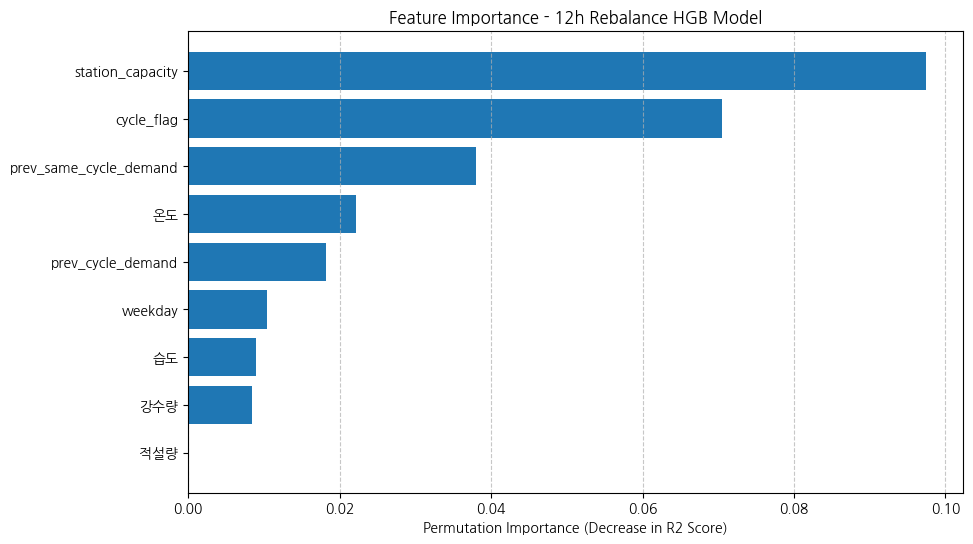

In [45]:
from sklearn.inspection import permutation_importance

result = permutation_importance(hgb_final, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(np.array(features)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel('Permutation Importance (Decrease in R2 Score)')
plt.title('Feature Importance - 12h Rebalance HGB Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
test_results = test[['시작_대여소_ID', 'datetime', target, 'station_capacity', 'cycle_flag']].copy()
test_results['predicted_future_12h_demand'] = np.expm1(hgb_final.predict(X_test))
test_results['predicted_future_12h_demand'] = test_results['predicted_future_12h_demand'].clip(lower=0)
test_results['hour'] = test_results['datetime'].dt.hour
test_results['cycle_label'] = np.where(test_results['hour'] == 4, '04_to_16', '16_to_04')
test_results['current_live_stock'] = test_results['station_capacity']
test_results['required_bikes'] = test_results['predicted_future_12h_demand'] - test_results['current_live_stock']
test_results['error'] = test_results['predicted_future_12h_demand'] - test_results[target]
test_results['abs_error'] = test_results['error'].abs()
test_results = test_results.sort_values(['시작_대여소_ID', 'datetime']).reset_index(drop=True)
display(test_results.head(20))

station_summary = (
    test_results.groupby('시작_대여소_ID')
    .agg(
        mean_actual=(target, 'mean'),
        mean_pred=('predicted_future_12h_demand', 'mean'),
        mae=('abs_error', 'mean'),
        rmse=('error', lambda x: float(np.sqrt(np.mean(np.square(x))))),
        mean_required=('required_bikes', 'mean')
    )
    .reset_index()
)
display(station_summary)


In [ ]:
for station_id in sorted(test_results['시작_대여소_ID'].unique()):
    print(f'===== {station_id} =====')
    station_view = test_results.loc[test_results['시작_대여소_ID'] == station_id, [
        'datetime', 'cycle_label', target, 'predicted_future_12h_demand',
        'current_live_stock', 'required_bikes', 'abs_error'
    ]].copy()
    display(station_view.tail(12))


In [ ]:
fig, axes = plt.subplots(len(test_results['시작_대여소_ID'].unique()), 1, figsize=(14, 4 * len(test_results['시작_대여소_ID'].unique())), sharex=True)
if len(test_results['시작_대여소_ID'].unique()) == 1:
    axes = [axes]

for ax, station_id in zip(axes, sorted(test_results['시작_대여소_ID'].unique())):
    station_plot = test_results[test_results['시작_대여소_ID'] == station_id].copy()
    ax.plot(station_plot['datetime'], station_plot[target], label='actual_12h_demand', marker='o', linewidth=1.5)
    ax.plot(station_plot['datetime'], station_plot['predicted_future_12h_demand'], label='predicted_12h_demand', marker='o', linewidth=1.5)
    ax.axhline(station_plot['station_capacity'].iloc[0], color='gray', linestyle='--', label='station_capacity')
    ax.set_title(f'{station_id} - 12h demand forecast vs actual')
    ax.set_ylabel('bikes')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
